<a href="https://colab.research.google.com/github/Bavesh-08/EDA-on-Penguin-Dataset/blob/main/penguin_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

df = pd.read_csv("/content/penguins_lter.csv")

print(f"Dataset Loaded Successfully! Shape: {df.shape}")
df.head(10)

Dataset Loaded Successfully! Shape: (344, 17)


,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
0,PAL0708,1,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A1,Yes,11/11/07,39.1,18.7,181.0,3750.0,MALE,NaN,NaN,Not enough blood for isotopes.
1,PAL0708,2,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A2,Yes,11/11/07,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454,NaN
2,PAL0708,3,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A1,Yes,11/16/07,40.3,18.0,195.0,3250.0,FEMALE,8.36821,-25.33302,NaN
3,PAL0708,4,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A2,Yes,11/16/07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult not sampled.
4,PAL0708,5,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N3A1,Yes,11/16/07,36.7,19.3,193.0,3450.0,FEMALE,8.76651,-25.32426,NaN
5,PAL0708,6,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N3A2,Yes,11/16/07,39.3,20.6,190.0,3650.0,MALE,8.66496,-25.29805,NaN
6,PAL0708,7,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N4A1,No,11/15/07,38.9,17.8,181.0,3625.0,FEMALE,9.18718,-25.21799,Nest never observed with full clutch.
7,PAL0708,8,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N4A2,No,11/15/07,39.2,19.6,195.0,4675.0,MALE,9.46060,-24.89958,Nest never observed with full clutch.
8,PAL0708,9,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N5A1,Yes,11/9/07,34.1,18.1,193.0,3475.0,NaN,NaN,NaN,No blood sample obtained.
9,PAL0708,10,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N5A2,Yes,11/9/07,42.0,20.2,190.0,4250.0,NaN,9.13362,-25.09368,No blood sample obtained for sexing.


In [ ]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   studyName            344 non-null    object 
 1   Sample Number        344 non-null    int64  
 2   Species              344 non-null    object 
 3   Region               344 non-null    object 
 4   Island               344 non-null    object 
 5   Stage                344 non-null    object 
 6   Individual ID        344 non-null    object 
 7   Clutch Completion    344 non-null    object 
 8   Date Egg             344 non-null    object 
 9   Culmen Length (mm)   342 non-null    float64
 10  Culmen Depth (mm)    342 non-null    float64
 11  Flipper Length (mm)  342 non-null    float64
 12  Body Mass (g)        342 non-null    float64
 13  Sex                  334 non-null    object 
 14  Delta 15 N (o/oo)    330 non-null    float64
 15  Delta 13 C (o/oo)    331 non-null    flo

,0
studyName,0
Sample Number,0
Species,0
Region,0
Island,0
Stage,0
Individual ID,0
Clutch Completion,0
Date Egg,0
Culmen Length (mm),2


In [ ]:

cols_to_drop = [
    'studyName', 'Sample Number', 'Region', 'Stage',
    'Individual ID', 'Clutch Completion', 'Date Egg',
    'Comments', 'Delta 15 N (o/oo)', 'Delta 13 C (o/oo)'
]
df_clean = df.drop(columns=cols_to_drop, errors='ignore')


num_cols = ['Culmen Length (mm)', 'Culmen Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)']
for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

df_clean['Sex'] = df_clean['Sex'].fillna(df_clean['Sex'].mode()[0])

df_clean = df_clean[df_clean['Sex'].isin(['MALE', 'FEMALE'])]

# 4. Simplify Target Variable strings (e.g., "Adelie Penguin (Pygoscelis adeliae)" -> "Adelie")
df_clean['Species'] = df_clean['Species'].apply(lambda x: x.split()[0])

print("Missing values after cleaning:")
print(df_clean.isnull().sum())

Missing values after cleaning:
Species                0
Island                 0
Culmen Length (mm)     0
Culmen Depth (mm)      0
Flipper Length (mm)    0
Body Mass (g)          0
Sex                    0
dtype: int64


/tmp/ipykernel_809/4001780602.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='Species', palette='viridis')


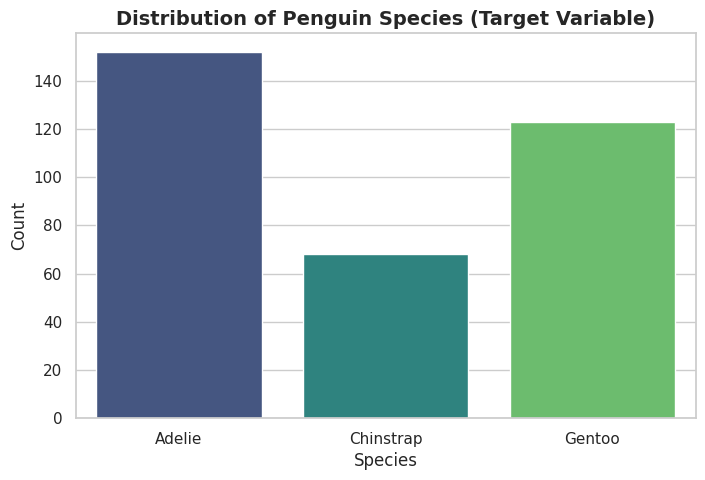

Species
Adelie       152
Gentoo       123
Chinstrap     68
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='Species', palette='viridis')
plt.title('Distribution of Penguin Species (Target Variable)', fontsize=14, fontweight='bold')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()

# Display exact counts
print(df_clean['Species'].value_counts())

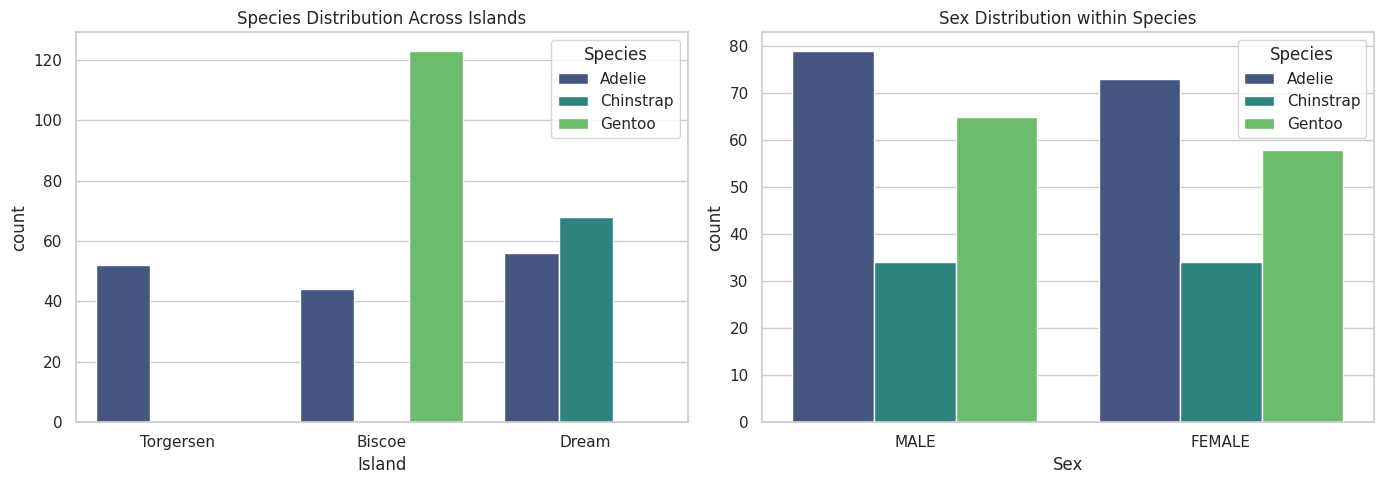

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Island vs Species
sns.countplot(data=df_clean, x='Island', hue='Species', palette='viridis', ax=axes[0])
axes[0].set_title('Species Distribution Across Islands')

# Plot 2: Sex vs Species
sns.countplot(data=df_clean, x='Sex', hue='Species', palette='viridis', ax=axes[1])
axes[1].set_title('Sex Distribution within Species')

plt.tight_layout()
plt.show()

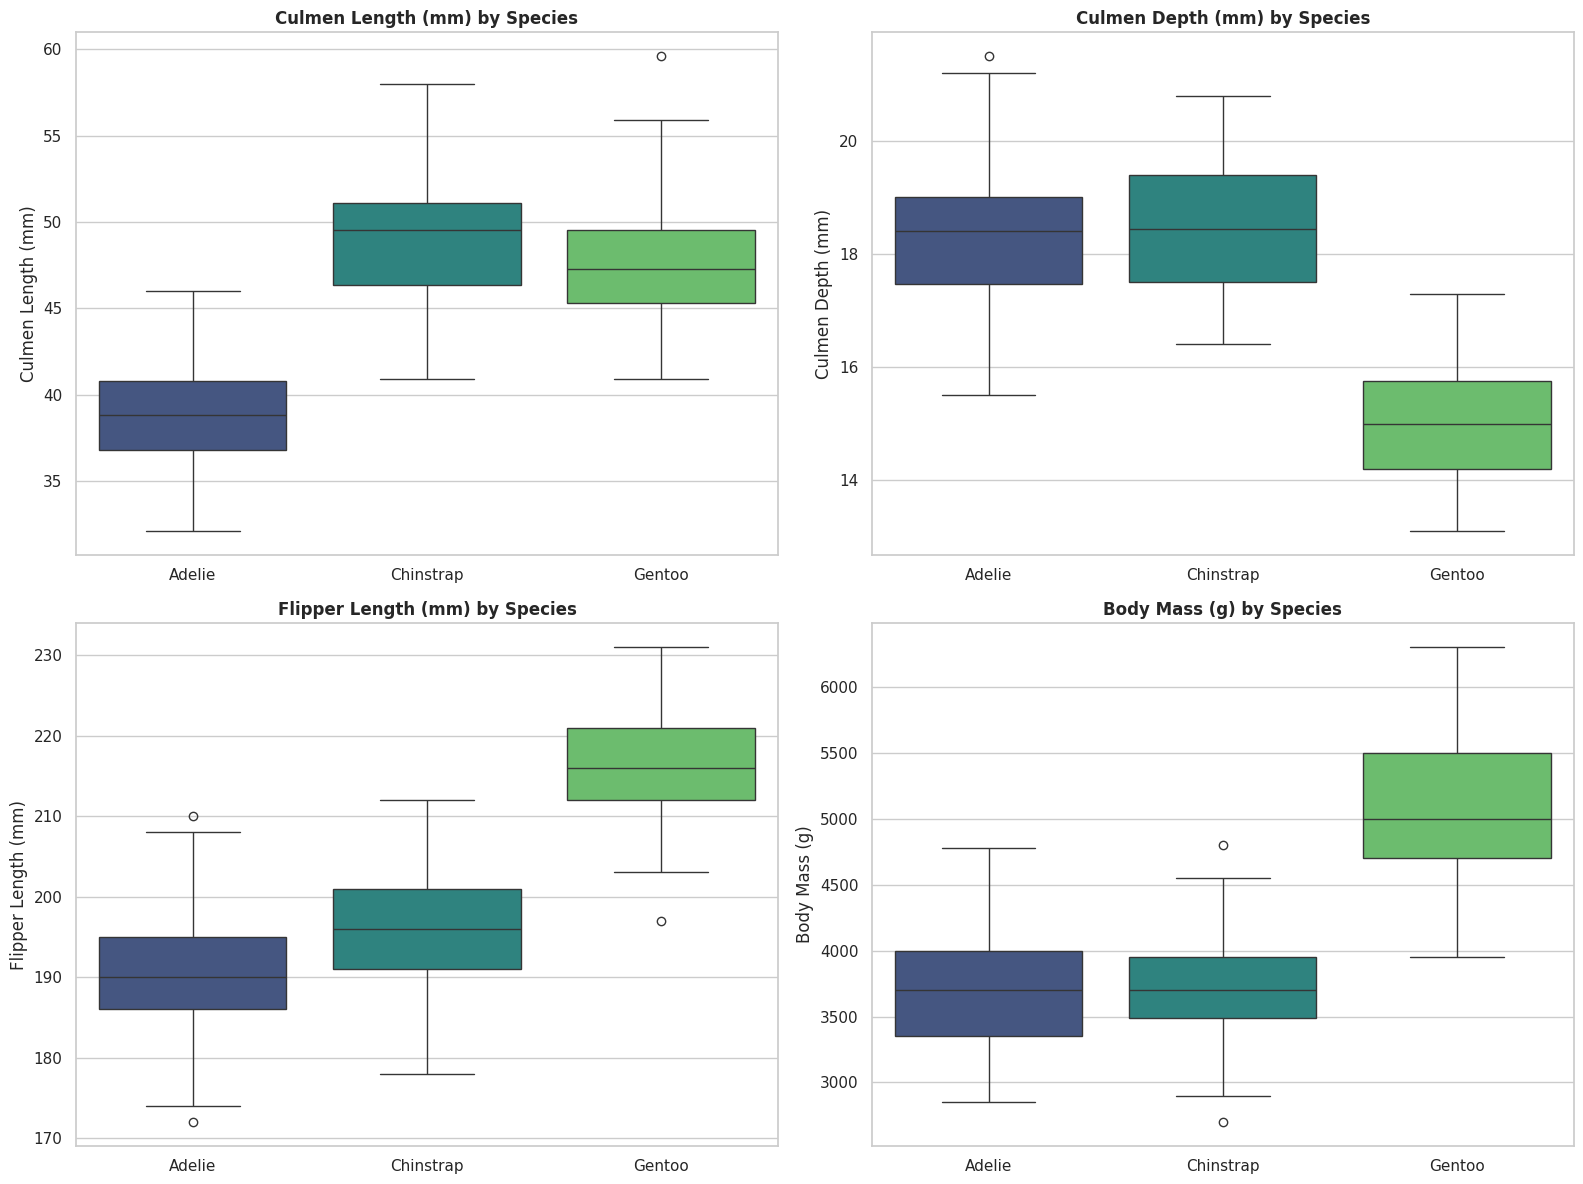

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df_clean, x='Species', y=col, hue='Species', palette='viridis', ax=axes[i], legend=False)
    axes[i].set_title(f'{col} by Species', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

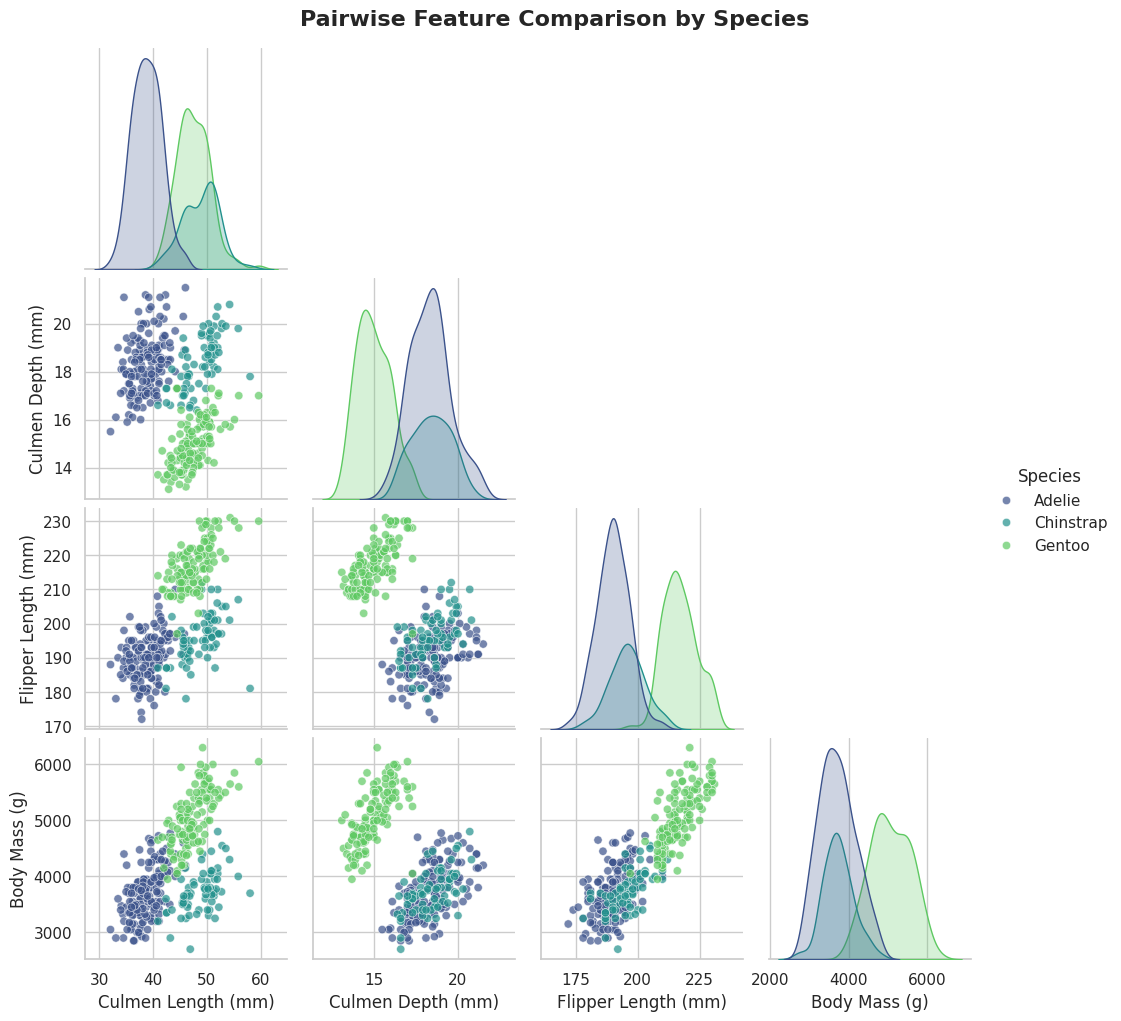

In [ ]:
# Create a pairplot color-coded by Species
pair_plot = sns.pairplot(
    df_clean,
    hue='Species',
    vars=num_cols,
    palette='viridis',
    corner=True,
    plot_kws={'alpha': 0.7}
)

pair_plot.fig.suptitle('Pairwise Feature Comparison by Species', y=1.02, fontsize=16, fontweight='bold')
plt.show()

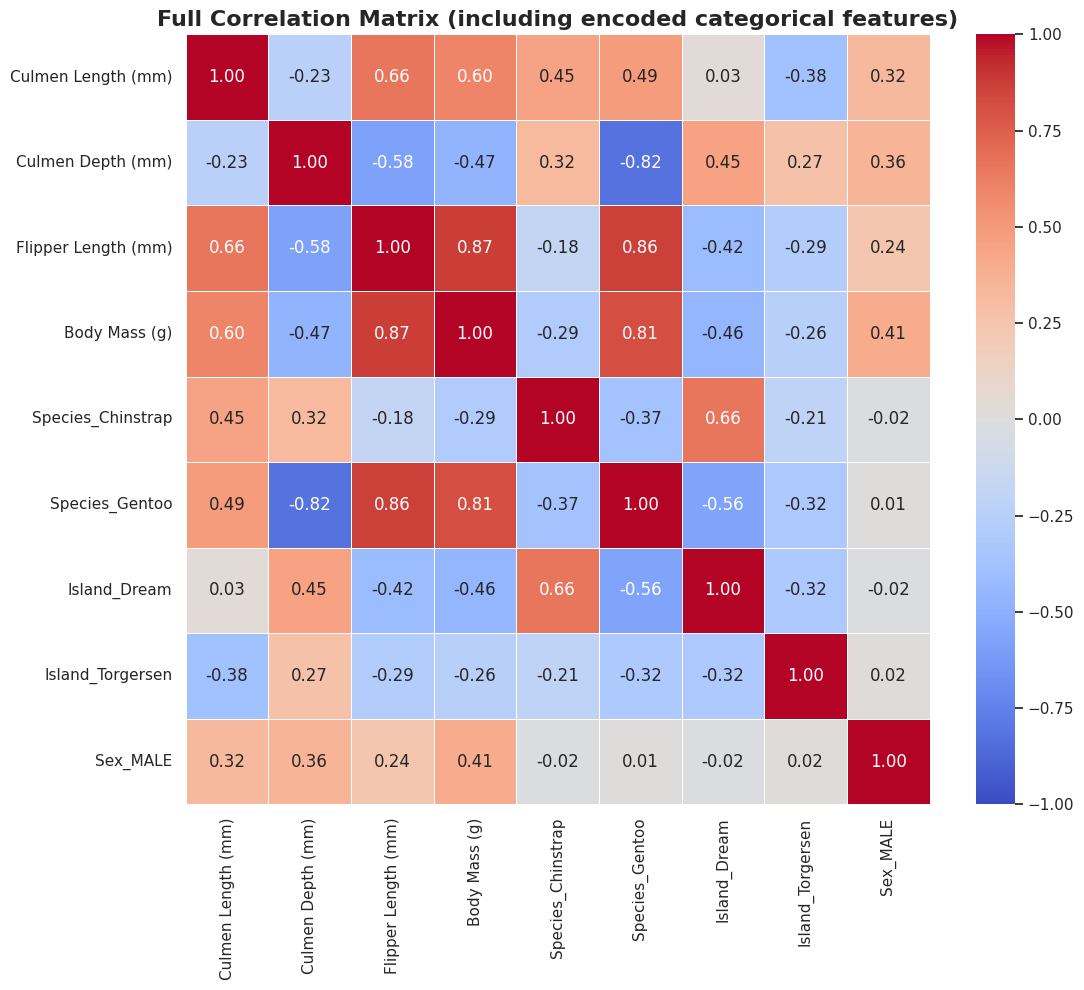

In [ ]:
df_encoded = df_clean.copy()

df_encoded = pd.get_dummies(df_encoded, columns=['Species', 'Island', 'Sex'], drop_first=True)

corr_matrix_full = df_encoded.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix_full,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=.5,
    vmin=-1,
    vmax=1
)
plt.title('Full Correlation Matrix (including encoded categorical features)', fontsize=16, fontweight='bold')
plt.show()

In [ ]:
print("\nFeatures highly dependent on Species:")

corr_with_gentoo = corr_matrix_full['Species_Gentoo'].sort_values(ascending=False).drop('Species_Gentoo')
print("\nCorrelations with Species_Gentoo:")
print(corr_with_gentoo)

corr_with_chinstrap = corr_matrix_full['Species_Chinstrap'].sort_values(ascending=False).drop('Species_Chinstrap')
print("\nCorrelations with Species_Chinstrap:")
print(corr_with_chinstrap)

print("\nTop absolute correlations with Species (combined):")

species_correlation_columns = [col for col in df_encoded.columns if 'Species_' in col]

absolute_species_correlations = pd.DataFrame()
for col in species_correlation_columns:
    abs_corr = corr_matrix_full[col].abs().sort_values(ascending=False).drop(species_correlation_columns)
    absolute_species_correlations[col] = abs_corr

display(absolute_species_correlations.head(10).style.background_gradient(cmap='coolwarm'))


df_temp = df_encoded.copy()
df_temp['Species_Adelie'] = 1 - (df_temp['Species_Gentoo'] + df_temp['Species_Chinstrap'])

corr_matrix_with_adelie = df_temp.corr()

print("\nCorrelations with Species_Adelie:")
corr_with_adelie = corr_matrix_with_adelie['Species_Adelie'].sort_values(ascending=False).drop('Species_Adelie')
print(corr_with_adelie)



Features highly dependent on Species:

Correlations with Species_Gentoo:
Flipper Length (mm)    0.864297
Body Mass (g)          0.814681
Culmen Length (mm)     0.491891
Sex_MALE               0.014224
Island_Torgersen      -0.316080
Species_Chinstrap     -0.371817
Island_Dream          -0.562639
Culmen Depth (mm)     -0.821319
Name: Species_Gentoo, dtype: float64

Correlations with Species_Chinstrap:
Island_Dream           0.660845
Culmen Length (mm)     0.448559
Culmen Depth (mm)      0.319545
Sex_MALE              -0.018860
Flipper Length (mm)   -0.178416
Island_Torgersen      -0.210205
Body Mass (g)         -0.289955
Species_Gentoo        -0.371817
Name: Species_Chinstrap, dtype: float64

Top absolute correlations with Species (combined):


,Species_Chinstrap,Species_Gentoo
Island_Dream,0.660845,0.562639
Culmen Length (mm),0.448559,0.491891
Culmen Depth (mm),0.319545,0.821319
Body Mass (g),0.289955,0.814681
Island_Torgersen,0.210205,0.316080
Flipper Length (mm),0.178416,0.864297
Sex_MALE,0.018860,0.014224



Correlations with Species_Adelie:
Culmen Depth (mm)      0.536478
Island_Torgersen       0.473860
Island_Dream           0.012821
Sex_MALE               0.001404
Species_Chinstrap     -0.443602
Body Mass (g)         -0.553817
Species_Gentoo        -0.667031
Flipper Length (mm)   -0.691236
Culmen Length (mm)    -0.834891
Name: Species_Adelie, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder


X = df_clean.drop('Species', axis=1)
y = df_clean['Species']

X = pd.get_dummies(X, columns=['Island', 'Sex'], drop_first=True)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.15, random_state=42, stratify=y_encoded)

scaler = StandardScaler()


numerical_cols_in_X = [col for col in X_train.columns if X_train[col].dtype in ['int64', 'float64']]

X_train[numerical_cols_in_X] = scaler.fit_transform(X_train[numerical_cols_in_X])
X_test[numerical_cols_in_X] = scaler.transform(X_test[numerical_cols_in_X])

print("Data preparation complete. X_train and X_test are scaled and encoded.")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

Data preparation complete. X_train and X_test are scaled and encoded.
X_train shape: (291, 7), y_train shape: (291,)
X_test shape: (52, 7), y_test shape: (52,)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear', multi_class='ovr'),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    'SVM': SVC(random_state=42, probability=True) # probability=True for ROC curve later
}

results = {}
best_estimators = {}

# Hyperparameter tuning parameters (simplified for demonstration)
# In a real scenario, these would be more extensive.
param_grids = {
    'Logistic Regression': {
        'C': [0.1, 1.0, 10.0]
    },
    'Random Forest': {
        'n_estimators': [50, 100],
        'max_depth': [None, 10]
    },
    'XGBoost': {
        'n_estimators': [50, 100],
        'learning_rate': [0.1, 0.2]
    },
    'SVM': {
        'C': [0.1, 1.0, 10.0],
        'kernel': ['linear', 'rbf']
    }
}

print("Starting model training and hyperparameter tuning...")

for name, model in models.items():
    print(f"\n--- Training {name} ---")
    grid_search = GridSearchCV(model, param_grids[name], cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    results[name] = accuracy
    best_estimators[name] = best_model

    print(f"Best parameters for {name}: {grid_search.best_params_}")
    print(f"Accuracy for {name}: {accuracy:.4f}")
    print(f"Classification Report for {name}:\n{classification_report(y_test, y_pred, target_names=label_encoder.classes_)}")

print("\n--- Model Training and Tuning Complete ---")
print("Overall Accuracies:", results)

# Determine the best model overall
best_model_name = max(results, key=results.get)
print(f"\nThe best performing model is: {best_model_name} with an accuracy of {results[best_model_name]:.4f}")


Starting model training and hyperparameter tuning...

--- Training Logistic Regression ---
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best parameters for Logistic Regression: {'C': 10.0}
Accuracy for Logistic Regression: 0.9808
Classification Report for Logistic Regression:
              precision    recall  f1-score   support

      Adelie       1.00      0.96      0.98        23
   Chinstrap       0.91      1.00      0.95        10
      Gentoo       1.00      1.00      1.00        19

    accuracy                           0.98        52
   macro avg       0.97      0.99      0.98        52
weighted avg       0.98      0.98      0.98        52


--- Training Random Forest ---
Fitting 3 folds for each of 4 candidates, totalling 12 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Best parameters for Random Forest: {'max_depth': None, 'n_estimators': 50}
Accuracy for Random Forest: 1.0000
Classification Report for Random Forest:
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        23
   Chinstrap       1.00      1.00      1.00        10
      Gentoo       1.00      1.00      1.00        19

    accuracy                           1.00        52
   macro avg       1.00      1.00      1.00        52
weighted avg       1.00      1.00      1.00        52


--- Training XGBoost ---
Fitting 3 folds for each of 4 candidates, totalling 12 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:21:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters for XGBoost: {'learning_rate': 0.1, 'n_estimators': 50}
Accuracy for XGBoost: 1.0000
Classification Report for XGBoost:
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        23
   Chinstrap       1.00      1.00      1.00        10
      Gentoo       1.00      1.00      1.00        19

    accuracy                           1.00        52
   macro avg       1.00      1.00      1.00        52
weighted avg       1.00      1.00      1.00        52


--- Training SVM ---
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best parameters for SVM: {'C': 1.0, 'kernel': 'linear'}
Accuracy for SVM: 1.0000
Classification Report for SVM:
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        23
   Chinstrap       1.00      1.00      1.00        10
      Gentoo       1.00      1.00      1.00        19

    accuracy                           1.00        52
   macro avg     

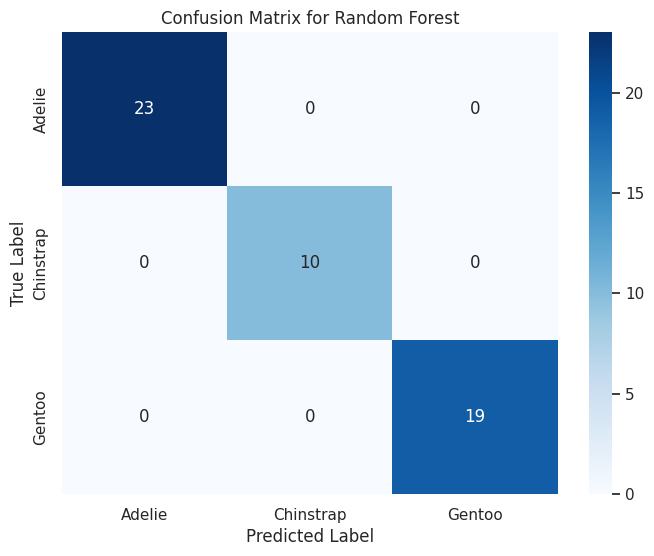


Metrics derived from Confusion Matrix for Random Forest:

Class: Adelie
  True Positives (TP): 23
  True Negatives (TN): 29
  False Positives (FP): 0
  False Negatives (FN): 0

Class: Chinstrap
  True Positives (TP): 10
  True Negatives (TN): 42
  False Positives (FP): 0
  False Negatives (FN): 0

Class: Gentoo
  True Positives (TP): 19
  True Negatives (TN): 33
  False Positives (FP): 0
  False Negatives (FN): 0


In [ ]:
from sklearn.metrics import confusion_matrix

# Get the best model and its predictions
best_model = best_estimators[best_model_name]
y_pred_best_model = best_model.predict(X_test)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_best_model)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix for {best_model_name}')
plt.show()

# Calculate and print TP, TN, FP, FN for each class
n_classes = len(label_encoder.classes_)

print(f"\nMetrics derived from Confusion Matrix for {best_model_name}:")
for i, class_name in enumerate(label_encoder.classes_):
    TP = cm[i, i]
    FN = np.sum(cm[i, :]) - TP
    FP = np.sum(cm[:, i]) - TP
    TN = np.sum(cm) - (TP + FN + FP)

    print(f"\nClass: {class_name}")
    print(f"  True Positives (TP): {TP}")
    print(f"  True Negatives (TN): {TN}")
    print(f"  False Positives (FP): {FP}")
    print(f"  False Negatives (FN): {FN}")